In [1]:
# ==========================================================================================
# PROJECT: Model-Independent Determination of the Sound Horizon (rd)
# COLLABORATION: BINGO Telescope / Observational Cosmology
# AUTHOR: Bruno Wesley
# ==========================================================================================

# SCIENTIFIC OBJECTIVE:
# To determine the sound horizon scale (rd) robustly without assuming a 
# background cosmology (e.g., LCDM). This approach calibrates the Baryon 
# Acoustic Oscillations (BAO) standard ruler using direct measurements 
# of the expansion rate H(z).

# METHODOLOGY:
# 1. H(z) Reconstruction: Utilizes Gaussian Processes (GP) via the GaPP 
#    package to infer the evolution of the Hubble parameter from Cosmic 
#    Chronometer (CC) data, avoiding parametric bias.
# 2. Uncertainty Propagation: Generation of 5,000 synthetic H(z) realizations 
#    using Cholesky factorization to construct the full covariance matrix 
#    for cosmological distances (DH, DM, DV).
# 3. BAO Projection: Interpolation of reconstructed distances onto the 
#    redshifts of observational data (DESI DR2) and construction of the 
#    theoretical vector d0/rd.
# 4. Bayesian Inference: Implementation of an MCMC (emcee) to sample the 
#    rd posterior distribution, incorporating both statistical data 
#    uncertainties and GP reconstruction systematic uncertainties.

# PRINCIPAL TOOLS:
# - GaPP (Gaussian Processes in Python)
# - Emcee (Ensemble Sampler for MCMC)
# - GetDist (Posterior Analysis and Plotting)
# - Scipy/Numpy/Pandas (Scientific Computing)
# ==========================================================================================

In [2]:
# ============================================================
# Standard scientific libraries
# ============================================================

import numpy as np
import scipy as sp
import pandas as pd
import warnings

from scipy.integrate import cumulative_simpson
from scipy.interpolate import interp1d
from scipy.linalg import inv, cho_factor, cho_solve

import matplotlib as mpl
import matplotlib.pyplot as plt

# ============================================================
# Gaussian Process (GaPP package)
# ============================================================

from gapp import gp
from gapp import covariance

# ============================================================
# MCMC and posterior analysis
# ============================================================

import emcee
import multiprocessing as mp
from getdist import MCSamples, plots
from IPython.display import display, Math

# ============================================================
# Plot configuration
# ============================================================

plt.rcParams['text.usetex'] = True

mpl.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "font.serif": ["Nimbus Roman"]
})

warnings.filterwarnings("ignore", category=UserWarning)

>
### **PHASE I — GP Reconstruction of $H(z)$**

**Scientific Objective**  
Reconstruct the expansion history $H(z)$ using CC data
through a GP with Squared Exponential (SE) kernel.

**Methodological Strategy**  
We model $H(z)$ as a GP with hyperparameters $(\ell, \sigma_f)$,
compute the posterior predictive distribution, and generate correlated
Monte Carlo realizations via Cholesky factorization.

**Inputs**
- CC measurements
- Measurement covariance matrix
- Kernel hyperparameters

**Outputs**
- GP mean reconstruction
- GP covariance matrix
- Monte Carlo realizations of $H(z)$
>

In [3]:
# ============================================================
# Load CC data
# ============================================================

# The CC dataset provides direct measurements of H(z)
# obtained from differential age techniques.

cc_dat_path = "/home/brunowesley/projetos/GaPP/CC_Hz_data.txt"

df_cc = pd.read_csv(cc_dat_path, sep=r"\s+")

# Extract columns as NumPy arrays for GP input
z_cc  = df_cc["z_cc"].to_numpy(float)       # Redshift
H_cc  = df_cc["H_cc"].to_numpy(float)       # H(z)
H_err = df_cc["H_cc_err"].to_numpy(float)   # Observational uncertainty


# Speed of light in km/s (used later for distance definitions)
c = 299792.458

In [4]:
# ============================================================
# GP reconstruction
# ============================================================

# We reconstruct H(z) in the redshift interval covered by the data.
# The GP is trained by maximizing the marginal likelihood.

# Reconstruction range
zmin = 0.0
zmax = np.max(z_cc)

# Instantiate GP with SE kernel
# This kernel assumes smooth behavior of H(z)
# Reconstruction grid (200 points)
g = gp.GaussianProcess(
    z_cc,
    H_cc,
    H_err,
    covfunction=covariance.SquaredExponential,
    cXstar=(zmin, zmax, 200) 
)

# Train hyperparameters and compute posterior mean + variance
rec, theta = g.gp(thetatrain="True")

# Extract reconstructed quantities following GaPP convention:
zrec     = rec[:, 0]  # z
hzrec    = rec[:, 1]  # mean
sighzrec = rec[:, 2]  # standard deviation

# Hubble constant estimate from z=0
H0    = hzrec[0]
sigH0 = sighzrec[0]

# Save reconstructed H(z)
# np.savetxt("Hz_CC_se_rec.dat", rec1)

# Print H0 and uncertanties
print(f"H0 = {H0:.3f} ± {sigH0:.3f} km/s/Mpc")


Optimized hyperparameters:
theta = [135.0243126    1.96180278]
H0 = 67.486 ± 4.577 km/s/Mpc


  NIT   NF   F                       GTG
    0    1  1.501586188990255E+02   2.44256527E+00
    1    4  1.490863511668585E+02   7.27421076E-02
    2    6  1.489905325599217E+02   9.61530268E-06
    3    8  1.489891921163452E+02   1.21642249E-03
    4   10  1.489865913849300E+02   1.57853066E-04
tnc: fscale = 36.4189
    5   12  1.489864760188026E+02   3.94671215E-07
    6   14  1.489864688067110E+02   1.36166564E-08
tnc: fscale = 3480.57
tnc: |fn-fn-1] = 1.28353e-08 -> convergence
    7   16  1.489864687938757E+02   4.98617821E-11
tnc: Converged (|f_n-f_(n-1)| ~= 0)


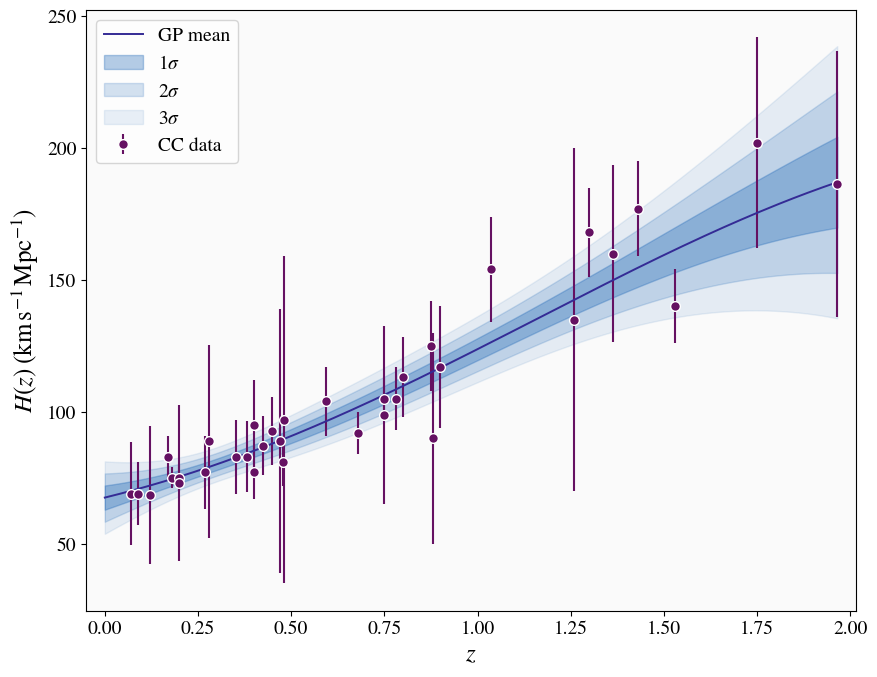

In [5]:
# =============================================================================
# Plotting: data + GP reconstruction
# =============================================================================

# Setting font style
plt.rcParams.update({
    "mathtext.fontset": "stix",
    "font.family": "STIXGeneral",
    "font.size": 14,
    "axes.labelsize": 18
})

# Figure size
fig, ax = plt.subplots(figsize=(9, 7))

# Axis labels
ax.set_xlabel(r"$z$")
ax.set_ylabel(r"$H(z)\;(\mathrm{km}\,\mathrm{s}^{-1}\,\mathrm{Mpc}^{-1})$")

# Axis limits
ax.set_xlim(zmin - 0.05, zmax + 0.05)

# Subtle background
ax.set_facecolor("#fafafa")

# Observational data
data_plot = ax.errorbar(
    z_cc,
    H_cc,
    yerr=H_err,
    fmt="o",
    markersize=7,
    markerfacecolor="#651162",
    markeredgecolor="white",
    ecolor="#651162",
    label=r"CC data"
)

# GP mean curve
mean_curve, = ax.plot(
    zrec,
    hzrec,
    color="#342B95",
    lw=1.4,
    label="GP mean"
)

# GP 1σ confidence region
band1 = ax.fill_between(
    zrec,
    hzrec - sighzrec,
    hzrec + sighzrec,
    color="#2a6fba",
    alpha=0.35,
    label=r"$1\sigma$"
)

# GP 2σ confidence region
band2 = ax.fill_between(
    zrec,
    hzrec - 2*sighzrec,
    hzrec + 2*sighzrec,
    color="#2a6fba",
    alpha=0.20,
    label=r"$2\sigma$"
)

# GP 3σ confidence region
band3 = ax.fill_between(
    zrec,
    hzrec - 3*sighzrec,
    hzrec + 3*sighzrec,
    color="#2a6fba",
    alpha=0.10,
    label=r"$3\sigma$"
)

# Legend
ax.legend(loc="best", frameon=True)

fig.tight_layout()

# Save and show figure
fig.savefig("Hz_CC_se_rec.png", dpi=300, bbox_inches="tight")
plt.show()

In [6]:
# ============================================================
# Construct full posterior predictive covariance matrix
# ============================================================

# The GP posterior covariance is:from numpy import loadtxt, savetxt

#              C_gp = K** − K* (K + Σ)^(-1) K*^T

# Where:
# K   : Covariance between observed CC data points
# Σ   : Observational noise (diagonal matrix of H_err^2)
# K*  : Cross-covariance between reconstruction grid and data
# K** : Prior covariance at reconstruction points


# Optimized hyperparameters
sigma_f, ell = theta

# Squared Exponential covariance calculation
def kernel(x1, x2):
    """
    Squared Exponential (SE) kernel:
    
        k(d) = σ_f^2 * exp(-d^2 / (2ℓ^2))
    
    This kernel is infinitely differentiable, assuming a very smooth behavior 
    for the reconstructed function. It is the standard choice for Gaussian 
    Process regression in cosmology due to its global smoothness.
    """
    
    x1 = np.atleast_2d(x1).T
    x2 = np.atleast_2d(x2).T
    sqdist = (x1 - x2.T)**2
    return sigma_f**2 * np.exp(-0.5 * sqdist / ell**2)


# Re-evaluate the kernel matrices
K = kernel(z_cc, z_cc)
Sigma = np.diag(H_err**2)
K_y = K + Sigma
K_star = kernel(zrec, z_cc)
K_starstar = kernel(zrec, zrec)

# Posterior predictive covariance
C_gp = K_starstar - K_star @ inv(K_y) @ K_star.T

# Add small jitter for numerical stability
C_gp += 1e-8 * np.eye(len(C_gp))

>
### **PHASE II — BAO Distances Construction**

**Scientific Objective**  
Construct cosmological distance measures derived from the reconstructed
expansion history $H(z)$.

**Methodological Strategy**  
Using each Monte Carlo realization of $H(z)$, we compute:

- Hubble distance $D_H(z)$
- Transverse comoving distance $D_M(z)$
- Volume-averaged distance $D_V(z)$

All uncertainties are propagated through Monte Carlo sampling.

**Inputs**
- Monte Carlo realizations of $H(z)$
- Speed of light ($c$)

**Outputs**
- $D_H(z)$
- $D_M(z)$
- $D_V(z)$
- Corresponding covariance matrices
>

In [7]:
# ============================================================
# Draw correlated GP realizations
# ============================================================

# We generate Monte Carlo realizations of H(z)
# to propagate full covariance into derived quantities.

mu = hzrec

# Cholesky factorization ensures correct correlation structure
L = np.linalg.cholesky(C_gp)

N_samples = 5000

# Each column corresponds to one GP realization
samples_H = mu[:, None] + L @ np.random.randn(len(zrec), N_samples)

In [8]:
# ============================================================
# Distance definitions
# ============================================================

# 1) Hubble distance
# D_H(z) = c / H(z)
samples_DH = c / samples_H

# 2) Comoving transverse distance
# D_M(z) = c ∫ dz / H(z)
integrand  = 1.0 / samples_H
samples_DM = c * cumulative_simpson(integrand, x=zrec, axis=0, initial=0.0)

# 3) Volume-averaged distance
# D_V(z) = [ z D_M(z)^2 D_H(z) ]^(1/3)
samples_DV = (zrec[:, None] * samples_DM**2 * samples_DH)**(1/3)
samples_DV[0, :] = 0.0

In [9]:
# ============================================================
# Monte Carlo mean and covariance
# ============================================================

# Mean reconstruction
mean_DH = np.mean(samples_DH, axis=1)
mean_DM = np.mean(samples_DM, axis=1)
mean_DV = np.mean(samples_DV, axis=1)

# Standard deviation (1σ uncertainty)
sig_DH = np.std(samples_DH, axis=1)
sig_DM = np.std(samples_DM, axis=1)
sig_DV = np.std(samples_DV, axis=1)

# Full covariance matrices (redshift-redshift correlations)
cov_DH = np.cov(samples_DH)
cov_DM = np.cov(samples_DM)
cov_DV = np.cov(samples_DV)

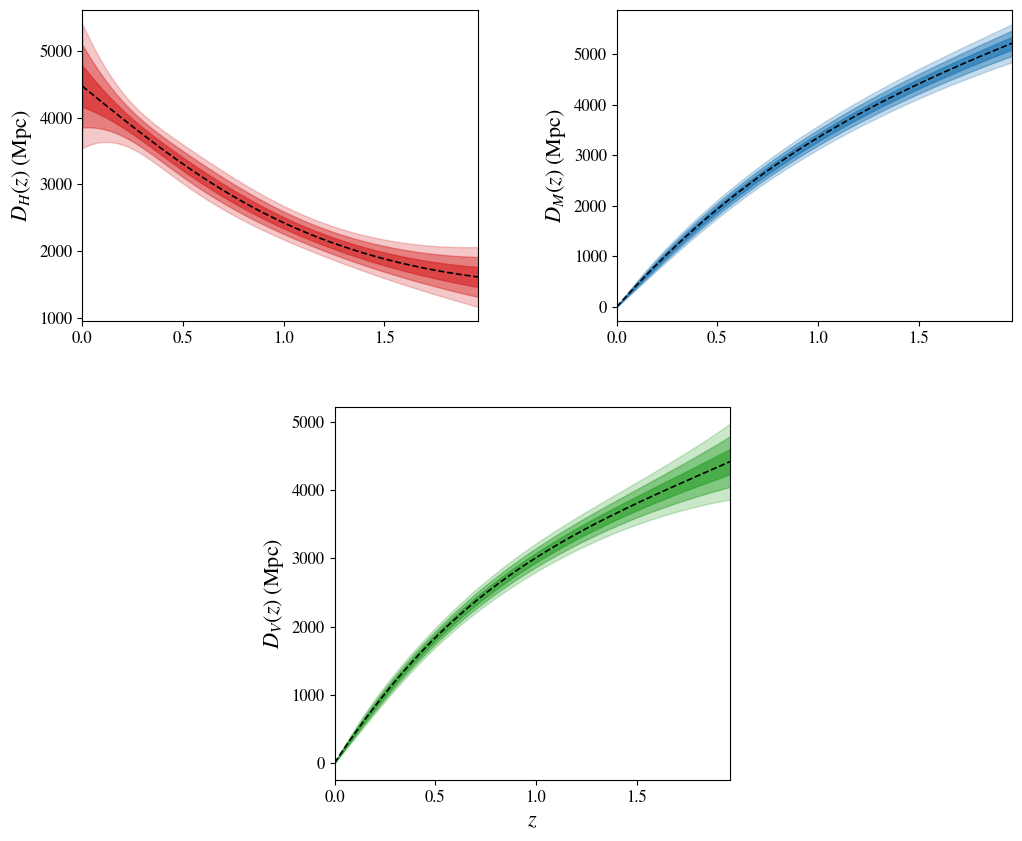

In [10]:
# =========================================================================
# Combined plot: DH(z), DM(z), DV(z) in custom layout (A, B, C)
# =========================================================================

fig = plt.figure(figsize=(12, 10))

# Create GridSpec: 2 rows, 2 columns
gs = fig.add_gridspec(
    nrows=2,
    ncols=2,
    height_ratios=[1, 1.2],  # bottom plot slightly taller
    hspace=0.25,
    wspace=0.35
)

# Axes definition
ax_DH = fig.add_subplot(gs[0, 0])   # Plot A
ax_DM = fig.add_subplot(gs[0, 1])   # Plot B
ax_DV = fig.add_subplot(gs[1, 0])   # Plot C (single column, will be centered)

# Center Plot C horizontally
pos = ax_DV.get_position()
new_width = pos.width
new_x0 = 0.5 - new_width / 2.0   # center horizontally

ax_DV.set_position([new_x0, pos.y0, new_width, pos.height])


# Plot A: DH(z)
ax_DH.plot(zrec, mean_DH, color="black", ls="--", lw=1.2)

ax_DH.fill_between(zrec, mean_DH - 3*sig_DH, mean_DH + 3*sig_DH,
                   color="#D62728", alpha=0.25)
ax_DH.fill_between(zrec, mean_DH - 2*sig_DH, mean_DH + 2*sig_DH,
                   color="#D62728", alpha=0.45)
ax_DH.fill_between(zrec, mean_DH - sig_DH, mean_DH + sig_DH,
                   color="#D62728", alpha=0.65)

ax_DH.set_ylabel(r"$D_H(z)\;(\mathrm{Mpc})$", fontsize=16)
ax_DH.tick_params(axis="both", labelsize=12)


# Plot B: DM(z)
ax_DM.plot(zrec, mean_DM, color="black", ls="--", lw=1.2)

ax_DM.fill_between(zrec, mean_DM - 3*sig_DM, mean_DM + 3*sig_DM,
                   color="#1f77b4", alpha=0.25)
ax_DM.fill_between(zrec, mean_DM - 2*sig_DM, mean_DM + 2*sig_DM,
                   color="#1f77b4", alpha=0.45)
ax_DM.fill_between(zrec, mean_DM - sig_DM, mean_DM + sig_DM,
                   color="#1f77b4", alpha=0.65)

ax_DM.set_ylabel(r"$D_M(z)\;(\mathrm{Mpc})$", fontsize=16)
ax_DM.tick_params(axis="both", labelsize=12)


# Plot C: DV(z)
ax_DV.plot(zrec, mean_DV, color="black", ls="--", lw=1.2)

ax_DV.fill_between(zrec, mean_DV - 3*sig_DV, mean_DV + 3*sig_DV,
                   color="#2CA02C", alpha=0.25)
ax_DV.fill_between(zrec, mean_DV - 2*sig_DV, mean_DV + 2*sig_DV,
                   color="#2CA02C", alpha=0.45)
ax_DV.fill_between(zrec, mean_DV - sig_DV, mean_DV + sig_DV,
                   color="#2CA02C", alpha=0.65)

ax_DV.set_xlabel(r"$z$", fontsize=16)
ax_DV.set_ylabel(r"$D_V(z)\;(\mathrm{Mpc})$", fontsize=16)
ax_DV.tick_params(axis="both", labelsize=12)


# Axis limits
ax_DH.set_xlim(zrec[0], zrec[-1])
ax_DM.set_xlim(zrec[0], zrec[-1])
ax_DV.set_xlim(zrec[0], zrec[-1])

# Save and show figure
fig.savefig("BAO_dist_se_rec.png", dpi=300, bbox_inches="tight")
plt.show()

>
### **PHASE III — BAO Data Projection into GP Space**

**Scientific Objective**  
Project the BAO observables into the reconstructed GP redshift grid
for consistent likelihood evaluation.

**Methodological Strategy**  
- Restrict BAO redshifts to the GP reconstruction domain.
- Interpolate Monte Carlo realizations of cosmological distances.
- Construct projected observables matching BAO measurements.
- Propagate full covariance through sampling.

**Inputs**  
- BAO dataset
- Monte Carlo distance realizations
- GP redshift grid

**Outputs**  
- Projected theoretical BAO predictions
- Covariance matrices in BAO space
>

In [11]:
# ============================================================
# Load BAO dataset
# ============================================================

# The BAO dataset contains measurements of D_H/r_d, D_M/r_d, and D_V/r_d
# from the DESI Collaboration (Data Release 2)

bao_dat_path = "/home/brunowesley/projetos/GaPP/desi_gaussian_bao_ALL_GCcomb_mean.txt"
bao_cov_path = "/home/brunowesley/projetos/GaPP/desi_gaussian_bao_ALL_GCcomb_cov.txt"

df_bao = pd.read_csv(
    bao_dat_path,
    sep=r"\s+",
    comment="#",
    names=["z", "value", "quantity"]
)

# Extract columns as NumPy arrays for likelihood construction
z_bao = df_bao["z"].values
d_obs = df_bao["value"].values
q_bao = df_bao["quantity"].str.lower().values

# Load BAO covariance matrix
cov_bao = np.loadtxt(bao_cov_path)


# ============================================================
# Redshift consistency between GP reconstruction and BAO data
# ============================================================

# Restrict BAO dataset to GP reconstruction range
mask = df_bao["z"] <= zrec.max()

df_bao = df_bao.loc[mask].reset_index(drop=True)

# Re-extract filtered BAO observables
z_bao = df_bao["z"].values
d_obs = df_bao["value"].values
q_bao = df_bao["quantity"].str.lower().values

# Apply redshift mask to BAO covariance matrix
cov_bao = cov_bao[np.ix_(mask, mask)]

In [12]:
# ============================================================
# Build theoretical BAO vector
# ============================================================

# Interpolate GP-reconstructed mean distances onto BAO redshifts
DH_interp = interp1d(zrec, mean_DH, kind="cubic")
DM_interp = interp1d(zrec, mean_DM, kind="cubic")


def d0_vector(z_arr, q_arr):
    """
    Compute the theoretical BAO distance vector evaluated at r_d = 1.

    This isolates the purely geometric dependence of the model,
    allowing the sound horizon parameter r_d to enter analytically as:

        d_theo(z) = d0(z) / r_d
    """

    # Interpolated distances at BAO redshifts
    dm = DM_interp(z_arr)
    dh = DH_interp(z_arr)
    dv = (z_arr * dm**2 * dh)**(1/3)

    # Initialize output vector
    d0 = np.empty_like(dm)

    # Identify observable type for each BAO entry
    mask_dv = np.array(["dv" in q for q in q_arr])
    mask_dm = np.array(["dm" in q for q in q_arr])
    mask_dh = np.array(["dh" in q for q in q_arr])

    # Assign corresponding theoretical prediction
    d0[mask_dv] = dv[mask_dv]
    d0[mask_dm] = dm[mask_dm]
    d0[mask_dh] = dh[mask_dh]

    return d0


def d_rec(rd, z_arr, q_arr):
    """
    Compute the theoretical BAO distance vector for arbitrary r_d.

    The model factorizes as:

        d_theo(z) = d0(z) / r_d
    """

    d0_vec = d0_vector(z_arr, q_arr)

    return d0_vec / rd

In [13]:
# =============================================================================
# BAO data vs. GP theoretical prediction — diagnostic comparison
# =============================================================================

def print_bao_comparison(rd, z_arr, q_arr, d_obs_arr):
    """
    Print a diagnostic table comparing observed BAO measurements
    with GP-based theoretical predictions for a given r_d.
    """

    # Compute theoretical BAO vector for the specified r_d
    d_theo = d_rec(rd, z_arr, q_arr)

    print(f"\nBAO comparison (r_d = {rd:.2f} Mpc)")
    print("-" * 80)
    print(f"{'z':<8} | {'d_obs':<12} | {'d_theo (GP)':<15} | {'diff (%)':<10} | {'quantity':<10}")
    print("-" * 80)

    for i in range(len(z_arr)):

        z = z_arr[i]
        obs = d_obs_arr[i]
        theo = d_theo[i]
        quant = q_arr[i]

        # Relative percentage difference
        diff = ((theo - obs) / obs) * 100

        print(f"{z:<8.3f} | {obs:<12.4f} | {theo:<15.4f} | {diff:<10.2f} | {quant:<10}")

    print("-" * 80)


rd_fid = 147.05
print_bao_comparison(rd_fid, z_bao, q_bao, d_obs)


BAO comparison (r_d = 147.05 Mpc)
--------------------------------------------------------------------------------
z        | d_obs        | d_theo (GP)     | diff (%)   | quantity  
--------------------------------------------------------------------------------
0.295    | 7.9417       | 8.0017          | 0.76       | dv_over_rs
0.510    | 13.5876      | 13.3842         | -1.50      | dm_over_rs
0.510    | 21.8629      | 22.3181         | 2.08       | dh_over_rs
0.706    | 17.3507      | 17.4967         | 0.84       | dm_over_rs
0.706    | 19.4553      | 19.7054         | 1.29       | dh_over_rs
0.934    | 21.5756      | 21.6868         | 0.52       | dm_over_rs
0.934    | 17.6415      | 17.1356         | -2.87      | dh_over_rs
1.321    | 27.6009      | 27.6483         | 0.17       | dm_over_rs
1.321    | 14.1760      | 13.8949         | -1.98      | dh_over_rs
1.484    | 30.5119      | 29.8294         | -2.24      | dm_over_rs
1.484    | 12.8170      | 12.8996         | 0.64       

In [14]:
# =============================================================================
# GP Covariance Projection at BAO Redshifts
# =============================================================================

def cov_gp_base(z_bao, q_bao):
    """
    Compute the GP-induced covariance matrix in BAO observable space,
    evaluated at r_d = 1.

    Monte Carlo realizations of the reconstructed distances are
    interpolated onto the BAO redshift grid. The empirical covariance
    matrix is then constructed from the projected samples.
    """

    n_bao = len(z_bao)

    # Matrix storing projected Monte Carlo samples
    # Shape: (n_observables, N_samples)
    samples_bao_space = np.zeros((n_bao, N_samples))

    # Interpolate Monte Carlo realizations
    interp_DH = interp1d(zrec, samples_DH, axis=0, kind='cubic')
    interp_DM = interp1d(zrec, samples_DM, axis=0, kind='cubic')
    interp_DV = interp1d(zrec, samples_DV, axis=0, kind='cubic')

    for i in range(n_bao):

        z_target = z_bao[i]
        quantity = q_bao[i]

        # Select appropriate observable
        if "dh" in quantity:
            samples_bao_space[i, :] = interp_DH(z_target)

        elif "dm" in quantity:
            samples_bao_space[i, :] = interp_DM(z_target)

        elif "dv" in quantity:
            samples_bao_space[i, :] = interp_DV(z_target)

    # Empirical covariance across Monte Carlo realizations
    return np.cov(samples_bao_space, rowvar=True)


def cov_gp(z_bao, q_bao, rd):
    """
    Compute the GP-induced covariance matrix in BAO observable space
    for arbitrary r_d.

    Since the theoretical distances scale as d_theo = d0 / r_d,
    the covariance scales as:

        C_theo = C0 / r_d^2
    """

    cov_gp_0 = cov_gp_base(z_bao, q_bao)

    return cov_gp_0 / rd**2

In [15]:
# =============================================================================
# Fiducial Consistency Check
# =============================================================================

# Compute GP-induced covariance at fiducial sound horizon value.
# This serves as a structural sanity check:
#   - Verify matrix symmetry
#   - Verify correct dimensionality
#   - Inspect magnitude scale

cov_test = cov_gp(z_bao, q_bao, rd_fid)

print("Covariance matrix shape:", cov_test.shape)
print("Is symmetric?:", np.allclose(cov_test, cov_test.T))
print("\nCovariance matrix:\n")
print(cov_test)

Covariance matrix shape: (11, 11)
Is symmetric?: True

Covariance matrix:

[[ 0.07461064  0.11005487  0.04344146  0.11312397 -0.0053235   0.10925199
  -0.02375565  0.10083115 -0.01523784  0.09902645 -0.00674185]
 [ 0.11005487  0.16558877  0.10054798  0.17734586  0.02775754  0.1787799
  -0.0088299   0.1726079  -0.01622751  0.17034319 -0.01117507]
 [ 0.04344146  0.10054798  0.43582925  0.1832941   0.3935002   0.26009551
   0.27379464  0.32246242  0.05397523  0.3247699  -0.0238427 ]
 [ 0.11312397  0.17734586  0.1832941   0.2054904   0.10880172  0.2234184
   0.05299759  0.23305667  0.00376726  0.23271963 -0.00725166]
 [-0.0053235   0.02775754  0.3935002   0.10880172  0.41507723  0.19648931
   0.34295321  0.29245752  0.14904424  0.31010552  0.0683217 ]
 [ 0.10925199  0.1787799   0.26009551  0.2234184   0.19648931  0.26066675
   0.13216037  0.2946975   0.04884988  0.30042225  0.02208621]
 [-0.02375565 -0.0088299   0.27379464  0.05299759  0.34295321  0.13216037
   0.34034431  0.24700915  0.24

>
### **PHASE IV — Bayesian Inference of the Sound Horizon $r_d$**

**Scientific Objective**  
Infer the posterior distribution of the sound horizon scale $r_d$
using BAO data combined with the GP-reconstructed cosmological distances.

**Methodological Strategy**

This phase combines:

1. Construction of the Gaussian likelihood.
2. Definition of the prior distribution.
3. Evaluation of the posterior probability.
4. Exploration of parameter space via MCMC sampling.

**Likelihood Model**

The theoretical BAO vector scales analytically as:

\begin{equation}
    d_{theo} = \frac{d_0}{r_d}
\end{equation}

The total covariance matrix is:

\begin{equation}
    C_{total} = C_{BAO} + \frac{C_0^{GP}}{r_d^2}
\end{equation}

The Gaussian log-likelihood is evaluated using Cholesky
factorization for numerical stability and efficient
computation of the inverse and log-determinant.

**Bayesian Inference**

The posterior is defined as:

\begin{equation}
    \ln{ [ P( r_d  \mid  \mathcal{D}) ] } = \ln{ [ L(\mathcal{D} \mid r_d) ] } + \ln{[\pi (r_d)]}
\end{equation}

where:
- $L$ is the Gaussian likelihood
- $\pi(r_d)$ is a uniform prior within physically motivated bounds
- $\mathcal{D}$ represents the data
  
The posterior distribution is sampled using an affine-invariant
ensemble Markov Chain Monte Carlo (MCMC) algorithm.

**Inputs**
- Observed BAO data vector
- BAO covariance matrix
- GP-projected theoretical vector
- GP covariance propagation
- Prior bounds on $r_d$

**Outputs**
- Posterior samples of $r_d$
- Maximum posterior estimate
- Credible intervals
- Corner plot visualization
- Summary statistics
>

In [16]:
# =====================================================
# Bayesian inference setup: priors and likelihood
# =====================================================

# ---------------------------------------------------------------------
# Pre-computation of base theoretical quantities
# ---------------------------------------------------------------------
# d0  : BAO theoretical vector evaluated at r_d = 1
# C0  : GP-propagated covariance evaluated at r_d = 1
#
# These quantities allow analytical scaling with r_d:
#
#   d_theo(r_d) = d0 / r_d
#   C_GP(r_d)   = C0 / r_d^2
#
# This avoids recomputing GP projections inside the MCMC loop,
# significantly improving computational efficiency.
# ---------------------------------------------------------------------

d0 = d0_vector(z_bao, q_bao)
C0 = cov_gp_base(z_bao, q_bao)


# ---------------------------------------------------------------------
# Log-prior definition
# ---------------------------------------------------------------------
# We adopt a uniform (flat) prior on the sound horizon r_d
# within physically motivated bounds.
#
# Outside this interval the prior probability is zero,
# which corresponds to log-prior = -∞.
# ---------------------------------------------------------------------

def log_prior(theta):
    
    rd = theta[0]
    
    # Uniform prior: r_d ∈ [100, 200] Mpc
    if not (100.0 <= rd <= 200.0):
        return -np.inf
        
    return 0.0


# ---------------------------------------------------------------------
# Gaussian log-likelihood
# ---------------------------------------------------------------------
# Statistical model:
#
#   d_theo(r_d) = d0 / r_d
#   C_tot(r_d)  = C_BAO + C0 / r_d^2
#
# The likelihood is:
#
#   -2 log L = (d_obs - d_theo)^T C_tot^{-1} (d_obs - d_theo)
#               + log det(C_tot) + N log(2π)
#
# Numerical implementation uses Cholesky factorization for:
#   - Stable matrix inversion
#   - Efficient log-determinant computation
# ---------------------------------------------------------------------

def log_likelihood(theta, d0, C0, d_obs, cov_bao):
    
    rd = theta[0] 
    
    # Theoretical BAO prediction
    d_theo = d0 / rd

    # Total covariance matrix
    # Combines observational BAO covariance and GP propagation
    C_tot = cov_bao + C0 / rd**2

    # Cholesky factorization:
    # C_tot = L L^T
    # Used for stable inversion and log(det C_tot)
    cho = cho_factor(C_tot)

    # Residual vector
    delta = d_obs - d_theo

    # χ² = δᵀ C⁻¹ δ
    chi2 = delta @ cho_solve(cho, delta)

    # log(det C_tot) from Cholesky diagonal
    logdet = 2.0 * np.sum(np.log(np.diag(cho[0])))

    # Number of data points
    n = len(d_obs)

    # Full Gaussian log-likelihood
    return -0.5 * (chi2 + logdet + n * np.log(2*np.pi))


# ---------------------------------------------------------------------
# Log-posterior
# ---------------------------------------------------------------------
# Bayes theorem (in log-space):
#
#   log P(r_d | 𝒟) = log L(𝒟 | r_d) + log π(r_d)
#
# We evaluate:
#   - Prior
#   - If valid, compute likelihood
# ---------------------------------------------------------------------

def log_probability(theta, d0, C0, d_obs, cov_bao):

    # Evaluate prior
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf

    # Evaluate likelihood
    ll = log_likelihood(theta, d0, C0, d_obs, cov_bao)

    return lp + ll


# =====================================================
# Validation: initial posterior evaluation
# =====================================================
# Evaluate the log-posterior at a fiducial value
# (e.g., Planck-inspired r_d ≈ 147 Mpc)
# to ensure the pipeline is numerically stable.
# =====================================================

theta = [147.05]
print("Log-probability =", log_probability(theta, d0, C0, d_obs, cov_bao))

Log-probability = -3.2374088978255466


In [17]:
# =====================================================
# MCMC configuration and posterior sampling
# =====================================================

# Sampling configuration
ndim, nwalkers, nsteps, nburn = 1, 20, 16500, 1500

# Reproducible random number generator
rng = np.random.default_rng(42)

# Initial walker positions
# Walkers are initialized by drawing from the prior distribution.
p0 = np.zeros((nwalkers, ndim))
p0[:, 0] = rng.uniform(100.0, 200.0, size=nwalkers)

# Parallel MCMC sampling
with mp.Pool(processes=mp.cpu_count()) as pool:

    sampler = emcee.EnsembleSampler(
        nwalkers,
        ndim,
        log_probability,
        args=(d0, C0, d_obs, cov_bao),
        pool=pool
    )

    sampler.run_mcmc(p0, nsteps, progress=True)

# Chain extraction
chain = sampler.get_chain()
flat_samples = sampler.get_chain(discard=nburn, flat=True)

# Save posterior samples for reproducibility
np.save("flat_samples_gp_se_rd_analysis.npy", flat_samples)

100%|██████████| 16500/16500 [00:35<00:00, 463.30it/s]


Removed no burn in


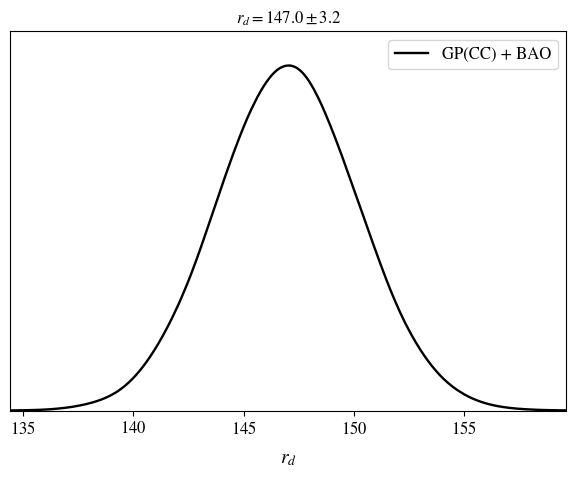

In [18]:
# ============================================================
# Posterior Visualization using GetDist
# ============================================================

# Parameter names and labels
param_names  = ["rd"]
param_labels = [r"r_d"]

samples = MCSamples(
    samples=flat_samples,
    names=param_names,
    labels=param_labels,
    label="GP + BAO"
)

# Smoothing and binning settings
# Note: smooth_scale_1D=0.25 is fine, but if it remains slow, 
# you can increase it to 0.3 for faster rendering.
samples.updateSettings({
    "smooth_scale_1D": 0.25,
    "fine_bins": 1024
})

# Initialize plotter for a single 1D plot (more stable for one parameter)
g = plots.get_single_plotter()
g.fig.set_size_inches(6, 5)

# Figure styling configuration
g.settings.axes_fontsize = 12
g.settings.lab_fontsize = 14
g.settings.legend_fontsize = 12
g.settings.linewidth_contour = 1.5
g.settings.axis_marker_lw = 1.0
g.settings.figure_legend_frame = False
g.settings.alpha_filled_add = 0.4

# Generate 1D plot with marginalized posterior
g.plot_1d(samples, "rd", filled=True, title_limit=1)

# Fix layout and spine issues
# Since it's a single plot, subplots[0,0] is our target axis
ax = g.subplots[0,0]
ax.patch.set_alpha(0)              # remove white background patch
ax.spines['top'].set_visible(True) # ensure top border is clean
ax.spines['right'].set_visible(True) # ensure right border is clean

# Add legend manually to ensure correct placement
g.add_legend(["GP(CC) + BAO"], legend_loc="best")

# Tighten layout before saving to prevent KeyboardInterrupt during render
plt.tight_layout()

# Save and show figure
plt.savefig("Corner_gp_se_rd_analysis.png", dpi=300)#, bbox_inches="tight")
plt.show()

In [19]:
# =============================================================================
# Marginalized Statistics Extraction for rd
# =============================================================================

# Extract marginalized statistics for the 'rd' parameter
stats = samples.getMargeStats().parWithName('rd')

# Mean and Standard Deviation (1-sigma)
mean_rd = stats.mean
err_rd  = stats.err

# Confidence limits (95% CL)
limit_95_lower = stats.limits[1].lower
limit_95_upper = stats.limits[1].upper

print(" "*50)
print("="*50)
print(f" FINAL INFERENCE RESULTS (Model-Independent) ")
print("="*50)
print(" "*50)
print(f"Sound Horizon rd: {mean_rd:.3f} ± {err_rd:.3f} Mpc (68% CL)")
print(f"95% CL Interval : [{limit_95_lower:.3f}, {limit_95_upper:.3f}] Mpc")
print(" "*50)
print("="*50)

latex_value = f"r_d = {mean_rd:.2f} \pm {err_rd:.2f}"
display(Math(f"\\text{{Inferred Sound Horizon: }} {latex_value} \\text{{ Mpc}}"))
print(" "*50)

                                                  
 FINAL INFERENCE RESULTS (Model-Independent) 
                                                  
Sound Horizon rd: 146.992 ± 3.229 Mpc (68% CL)
95% CL Interval : [140.676, 153.331] Mpc
                                                  


<IPython.core.display.Math object>

In [20]:
# =============================================================================
# MCMC Convergence Diagnostics (Autocorrelation & Gelman-Rubin)
# =============================================================================

def gelman_rubin_diagnostic(chain_sample):
    """
    Computes the Potential Scale Reduction Factor (R-hat).
    Expects chain in the shape (steps, walkers, parameters).
    """
    
    n_steps, n_walkers, _ = chain_sample.shape
    
    # Between-chain variance (B)
    chain_means = np.mean(chain_sample, axis=0)
    grand_mean = np.mean(chain_means, axis=0)
    B = (n_steps / (n_walkers - 1)) * np.sum((chain_means - grand_mean)**2, axis=0)
    
    # Within-chain variance (W)
    chain_vars = np.var(chain_sample, axis=0, ddof=1)
    W = np.mean(chain_vars, axis=0)
    
    # Estimated target variance
    V_hat = ((n_steps - 1) / n_steps) * W + (B / n_steps)
    R_hat = np.sqrt(V_hat / W)
    
    return R_hat


# -------------------------------------------------------------------
# Execution and Calculations
# -------------------------------------------------------------------

# Autocorrelation Time (tau)
tau_array = sampler.get_autocorr_time(quiet=True)
tau = tau_array[0]
n_eff = nsteps - nburn
converged_tau = n_eff > 50 * tau

# Gelman-Rubin (R-hat)
r_hat = gelman_rubin_diagnostic(chain[nburn:, :, :])


# -------------------------------------------------------------------
# Output Summary
# -------------------------------------------------------------------

print("\n" + "="*55)
print(f"{'MCMC CONVERGENCE SUMMARY':^55}")
print("="*55)

# Autocorrelation Block
print(f"{'Autocorrelation Time (τ):':<35} {tau:>10.2f} steps")
print(f"{'Safety Factor (n_eff / τ):':<35} {n_eff / tau:>10.2f}x")
status_tau = "PASSED" if converged_tau else "FAILED"
print(f"{'Status (Safety Factor > 50):':<35} {status_tau:>10}")

print("-" * 55)

# Gelman-Rubin Block
print(f"{'Gelman-Rubin (R-hat):':<35} {r_hat[0]:>10.4f}")
status_rhat = "PASSED" if r_hat[0] < 1.01 else "FAILED"
print(f"{'Status (R-hat < 1.01):':<35} {status_rhat:>10}")

print("="*55 + "\n")


               MCMC CONVERGENCE SUMMARY                
Autocorrelation Time (τ):                29.03 steps
Safety Factor (n_eff / τ):              516.66x
Status (Safety Factor > 50):            PASSED
-------------------------------------------------------
Gelman-Rubin (R-hat):                   1.0009
Status (R-hat < 1.01):                  PASSED



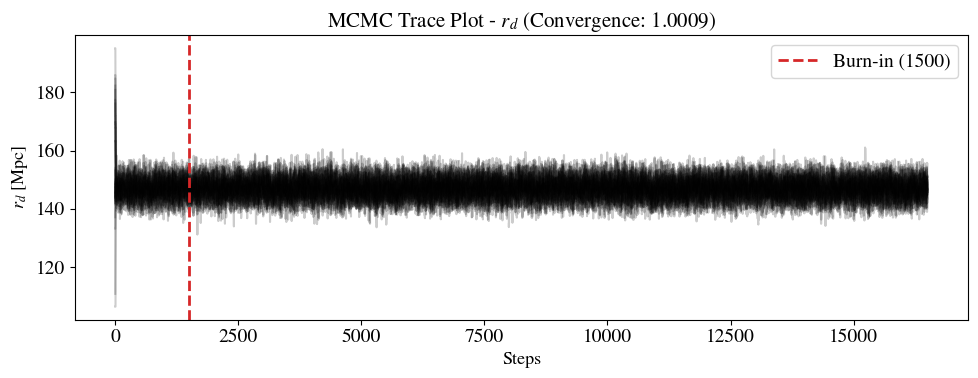

In [21]:
# =============================================================================
# Trace plot for the sound horizon (rd) parameter
# =============================================================================

fig, ax = plt.subplots(figsize=(10, 4))

# Plot the trajectory of each walker for rd
# The chain has the shape (steps, walkers, parameters)
# chain[:, :, 0] accesses all steps and walkers for the first parameter (rd)
ax.plot(chain[:, :, 0], color="k", alpha=0.2)

# Vertical line marking the end of the burn-in phase
# Samples before this line are discarded to remove initial bias
ax.axvline(nburn, color="#d62728", linestyle="--", lw=2, label=f"Burn-in ({nburn})")

# Title displaying the R-hat convergence diagnostic
ax.set_title(f"MCMC Trace Plot - $r_d$ (Convergence: {r_hat[0]:.4f})", fontsize=15)
ax.set_xlabel("Steps", fontsize=13)
ax.set_ylabel("$r_d$ [Mpc]", fontsize=13)

# Place legend to identify the burn-in threshold
ax.legend(loc="upper right")

plt.tight_layout()
plt.show()

In [22]:
# =============================================================================
# Model Selection & Quality of Fit (Model-Independent)
# =============================================================================

# Finding the best-fit (maximum log-likelihood)
log_prob_samples = sampler.get_log_prob(discard=nburn, flat=True)
max_log_like = np.max(log_prob_samples)

# Number of free parameters (k) and observations (N)
k = ndim  # k = 1 (rd)
N = len(d_obs)

# AIC & BIC
aic = 2*k - 2*max_log_like
bic = k * np.log(N) - 2*max_log_like

# Best-fit Chi-square
# Note: Log-likelihood = -0.5 * chi2 + constant
# To get the exact chi2, we calculate it at the best-fit rd
best_theta = flat_samples[np.argmax(log_prob_samples)]
best_rd = best_theta[0]

# Simplified chi2 from the log-likelihood definition:
chi2_min = -2 * max_log_like - N * np.log(2*np.pi) 
red_chi2 = chi2_min / (N - k)

print("\n" + "="*50)
print(f"{'STATISTICAL QUALITY OF RECONSTRUCTION':^50}")
print("="*50)
print(f"{'Best-fit rd:':<35} {best_rd:>10.2f} Mpc")
print(f"{'Reduced χ² (χ²/dof):':<35} {red_chi2:>10.2f}")
print("-" * 50)
print(f"{'Akaike Information (AIC):':<35} {aic:>10.2f}")
print(f"{'Bayesian Information (BIC):':<35} {bic:>10.2f}")
print("="*50 + "\n")


      STATISTICAL QUALITY OF RECONSTRUCTION       
Best-fit rd:                            147.01 Mpc
Reduced χ² (χ²/dof):                     -1.37
--------------------------------------------------
Akaike Information (AIC):                 8.47
Bayesian Information (BIC):               8.87

